In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("airbnb.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194
4,668,NaN,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206


## 1. Handle missing / NaN values
   - Find all missing values in the dataset.
   - Fill NaN values using a proper strategy (mean, median, mode, or a suitable placeholder depending on the column). Explain why you chose that method.

In [5]:
df.isnull().sum()

id                                  0
name                              271
host_id                             0
host_name                         127
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      1
availability_365                    0
dtype: int64

In [7]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Axes: >

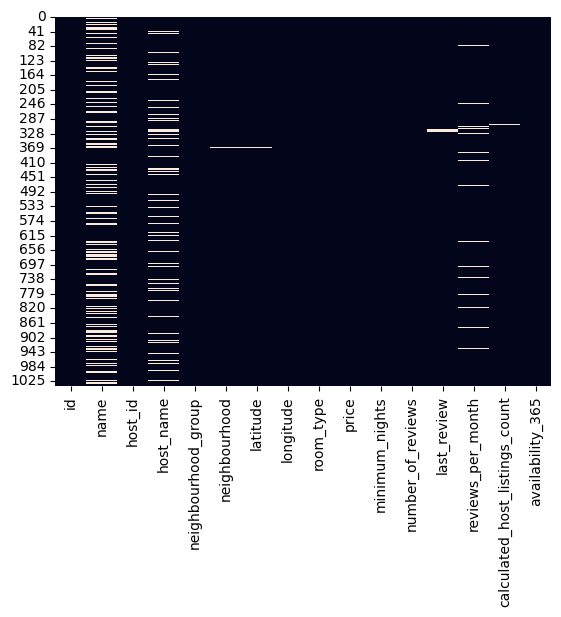

In [9]:
sns.heatmap(df.isnull(), cbar=False)

Text(0.5, 1.0, 'Missing Values Heatmap')

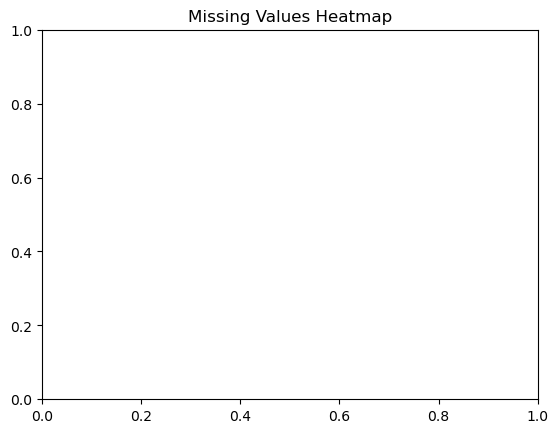

In [11]:
plt.title("Missing Values Heatmap")

In [15]:
plt.show()

In [21]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [25]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

## 2. Handle duplicate values
   - Detect duplicate rows in the dataset.
   - Remove all duplicates.

In [27]:
df.duplicated().sum()

31

In [30]:
df = df.drop_duplicates()

In [34]:
df.duplicated().sum()

0

## 4. Fix data types
   - Some columns have the wrong data type (for example, price is stored as text). Convert them to the correct type.

In [47]:
cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "longitude"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [51]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [42]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778.0,5.0,36.0,4/9/2019,4.86,19.0,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178.0,1.0,377.0,14/10/2014,0.46,7.0,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72.0,365.0,99.0,11/8/2013,1.99,19.0,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365.0,1.0,298.0,3/17/2018,7.21,8.0,194
4,668,Spacious 2BR,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244.0,1.0,186.0,1/3/2012,2.05,20.0,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,920,Spacious 2BR,35854,Robert,BRONX,Mott Haven,40.54088,-74.04306,Entire home/apt,108.0,5.0,296.0,14/11/2014,5.43,18.0,422
1036,212,Quiet private room,32502,John,The Bronx,Fordham,40.63243,-73.98257,Shared room,139.0,1000.0,271.0,9/27/2018,0.43,20.0,342
1037,503,Beautiful loft,43343,Daniel,QUEENS,Astoria,40.55864,-74.04089,PRIVATE ROOM,24482.0,30.0,369.0,2/4/2018,4.28,5.0,142
1038,538,Quiet private room,43317,David,BROOKLYN,Bedford-Stuyvesant,40.89359,-73.90267,private room,0.0,1.0,191.0,1/8/2012,8.26,14.0,71


## 3. Detect outliers
   - Identify outliers in the numeric columns (for example: price, minimum_nights, availability_365).
   - Show them using a method of your choice (IQR, boxplot, etc.) and handle them appropriately.

In [53]:
numeric_cols = [
    "price",
    "minimum_nights",
    "availability_365"
]


for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col)
    print("Outliers:", len(outliers))

price
Outliers: 41
minimum_nights
Outliers: 199
availability_365
Outliers: 0


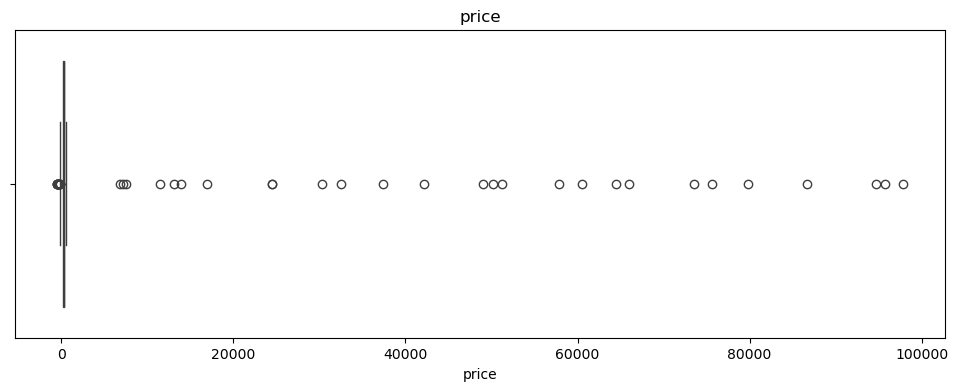

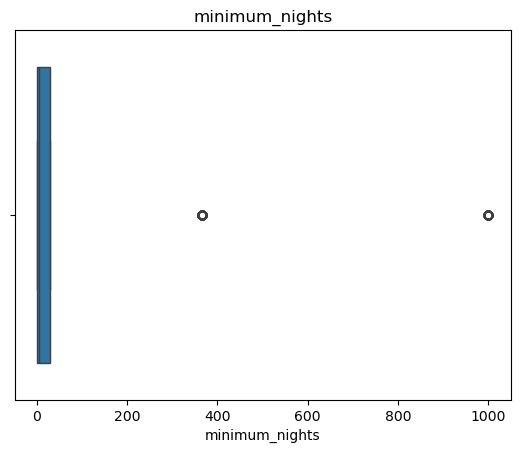

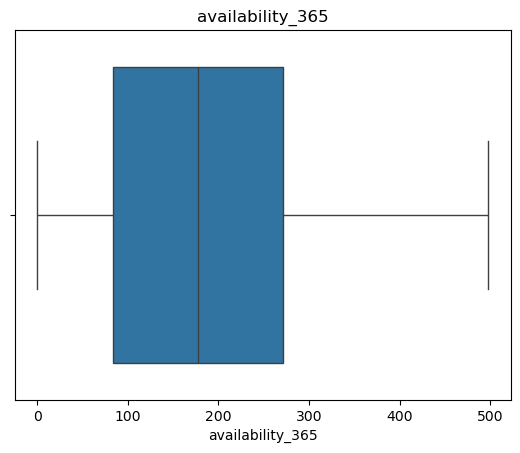

In [55]:
plt.figure(figsize=(12,4))

for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [57]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    df[col] = np.where(
        df[col] < lower,
        lower,
        np.where(df[col] > upper, upper, df[col])
    )

## 5. Convert discrete values into continuous
   - Where required, convert discrete values into continuous values.

In [60]:
df["minimum_nights"] = df["minimum_nights"].astype(float)

df["availability_365"] = df["availability_365"].astype(float)

## 6. Visualization (plots)
   - Create proper plots/graphs for your cleaned data (missing values heatmap, price distribution, room type counts, neighbourhood group analysis, etc.).

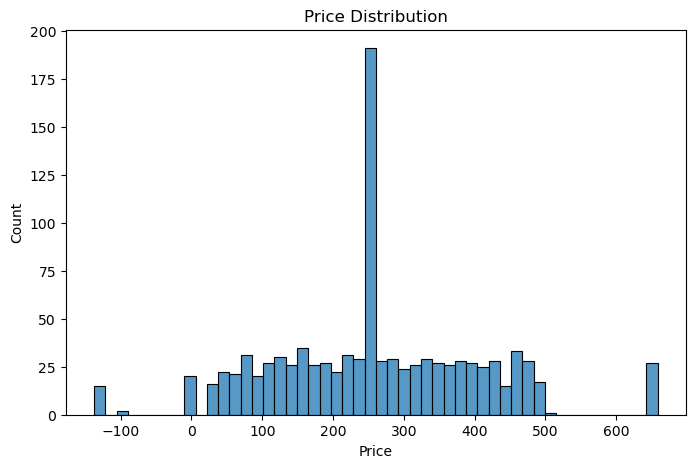

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=50)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

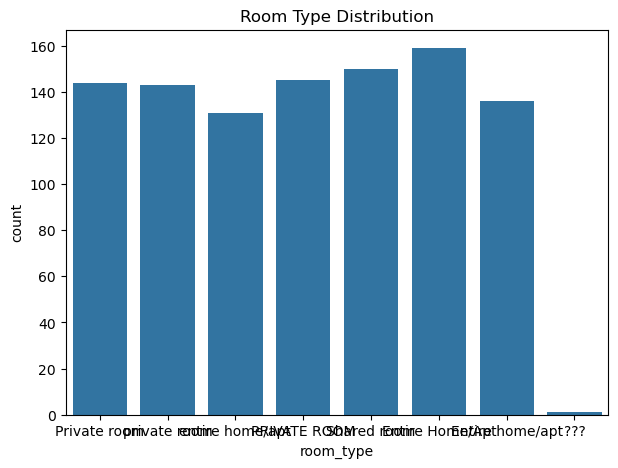

In [65]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="room_type"
)

plt.title("Room Type Distribution")

plt.show()

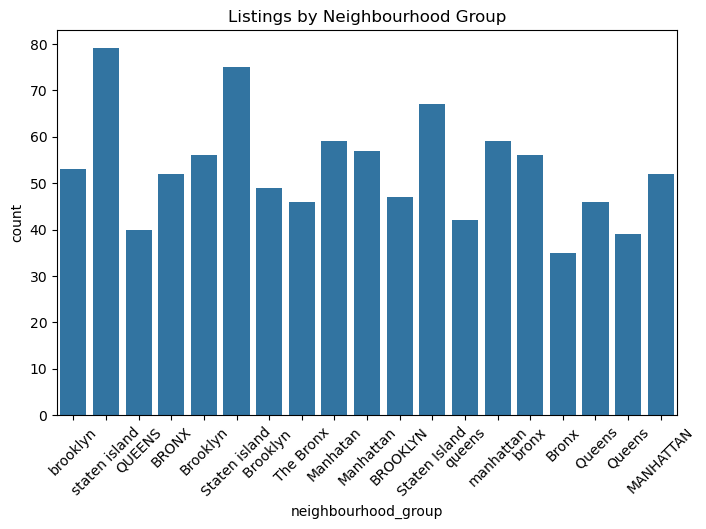

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="neighbourhood_group"
)

plt.title("Listings by Neighbourhood Group")

plt.xticks(rotation=45)

plt.show()

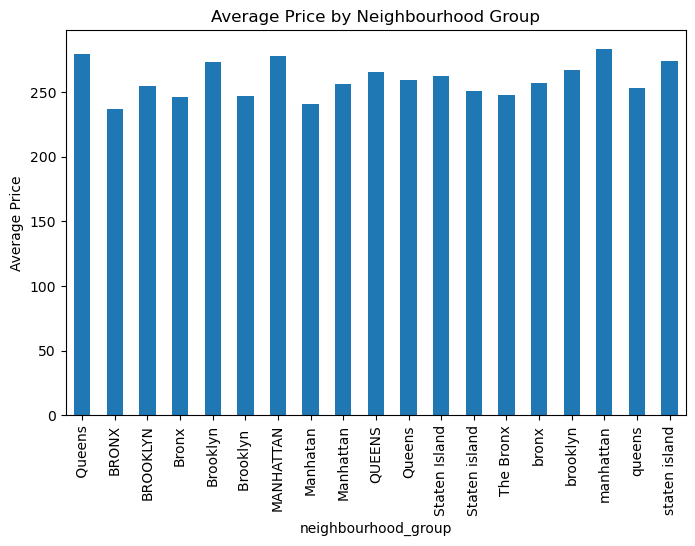

In [69]:
avg_price = df.groupby(
    "neighbourhood_group"
)["price"].mean()


avg_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Price by Neighbourhood Group")

plt.ylabel("Average Price")

plt.show()

## 7. Final verification (very important)
   - At the END of your file, use df.info() and df.isnull().sum() to show that the data is now fully cleaned and has no missing values left.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1009 non-null   object 
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1009 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           1009 non-null   float64
 10  minimum_nights                  1009 non-null   float64
 11  number_of_reviews               1009 non-null   float64
 12  last_review                     1009 no

In [74]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64